# M7 · Ranking & CTR — A Complete pCTR Model, Step by Tiny Step

**Companion to curriculum lesson M7. Written for someone brand new to ML.**

We build one **pCTR** model. "pCTR" = **predicted Click-Through Rate**: for each ad we
show a person, predict the *probability they click it* (a number from 0 to 1, e.g.
`0.04` = "about a 4% chance"). Ad systems rank ads by this probability (times the bid).

**What makes this notebook different:** it's *granular*. We don't call one magic
`.fit()` — we build the model **from scratch** and **watch it learn**, printing the
error going down each step. Every stage has a picture and a short plain-English "why."

**Roadmap:** make data → look at it → split → **standardize** → build the math
(sigmoid, loss, gradient) → **train with a logged loop** → check it recovered the true
rule → predict → measure ranking (AUC) → measure honesty (calibration) → rank ads →
`pCTR × bid` → **four proof graphs**.

Run each cell with **Shift+Enter**. Read the text first — it explains the cell below it.

## Step 1a · Create the features

Each **example** is one ad shown to one person (an *impression*). **Features** are things
we know *before* showing the ad. We'll make 6,000 impressions with four features:
- `relevance` (0–1): how well the ad matches the person.
- `position` (1–10): slot on the page (1 = top).
- `ad_quality` (0–1): how good the ad is in general.
- `is_mobile` (0/1): phone or desktop.

We just print each feature's range so we can *see* what we made — that's our first bit of
**logging**.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N = 6000

relevance  = rng.uniform(0, 1, N)
position   = rng.integers(1, 11, N)
ad_quality = rng.uniform(0, 1, N)
is_mobile  = rng.integers(0, 2, N)

for name, col in [("relevance", relevance), ("position", position),
                  ("ad_quality", ad_quality), ("is_mobile", is_mobile)]:
    print(f"{name:<11} range [{col.min():.2f}, {col.max():.2f}]  mean {col.mean():.2f}")

relevance   range [0.00, 1.00]  mean 0.50
position    range [1.00, 10.00]  mean 5.48
ad_quality  range [0.00, 1.00]  mean 0.51
is_mobile   range [0.00, 1.00]  mean 0.50


## Step 1b · Invent the TRUE rule, then generate clicks

Here's the trick that lets us *prove* the model works later: **we** decide the real rule
behind clicks. We combine the features into a **score** (called a *logit*), squash it to a
probability with the **sigmoid** function, then flip a weighted coin to decide the click.

The rule (remember these numbers — the model will have to rediscover them):
`logit = -3.0 + 3.0·relevance + 1.5·ad_quality − 0.25·position + 0.4·is_mobile`

Positive numbers push clicks **up** (relevance, quality, mobile); the negative one on
`position` means lower on the page → fewer clicks.

In [2]:
TRUE_WEIGHTS = {"relevance": 3.0, "position": -0.25, "ad_quality": 1.5, "is_mobile": 0.4}
TRUE_BIAS = -3.0

true_logit = (TRUE_BIAS + 3.0*relevance + 1.5*ad_quality - 0.25*position + 0.4*is_mobile)
true_pctr  = 1 / (1 + np.exp(-true_logit))            # sigmoid: score -> probability (0..1)
clicked    = (rng.random(N) < true_pctr).astype(int)  # flip a coin with that probability

data = pd.DataFrame(dict(relevance=relevance, position=position, ad_quality=ad_quality,
                         is_mobile=is_mobile, true_pctr=true_pctr, clicked=clicked))
print("overall click rate:", round(data.clicked.mean(), 3),
      " (so about", int(100*data.clicked.mean()), "clicks per 100 impressions)")
print("true_pctr ranges from", round(true_pctr.min(),3), "to", round(true_pctr.max(),3))
data.head()

overall click rate: 0.174  (so about 17 clicks per 100 impressions)
true_pctr ranges from 0.005 to 0.819


## Step 2a · Look at each feature's shape

Always *look* at your data. Histograms show how each feature is spread out. `relevance`,
`ad_quality` are flat (uniform), `position` is spread across 1–10, `is_mobile` is two bars.

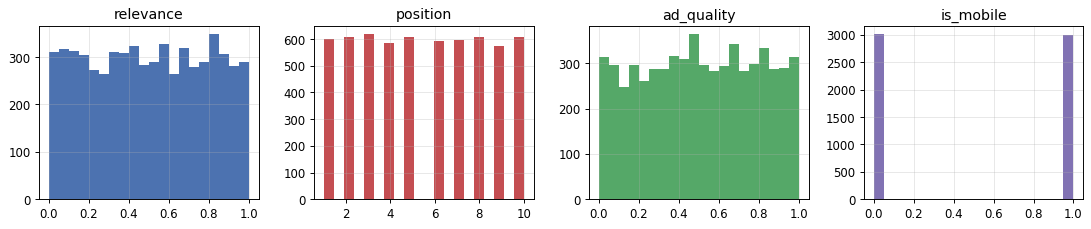

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(13, 2.8))
for a, (name, col, color) in zip(ax, [("relevance", relevance, BLUE), ("position", position, RED),
                                      ("ad_quality", ad_quality, GREEN), ("is_mobile", is_mobile, PURPLE)]):
    a.hist(col, bins=20, color=color); a.set_title(name)
plt.show()

## Step 2b · Does each feature actually affect clicks?

If our rule is real, click rate should **rise** with relevance/quality and **fall** as
position goes down the page. If these were flat lines, there'd be nothing to learn.

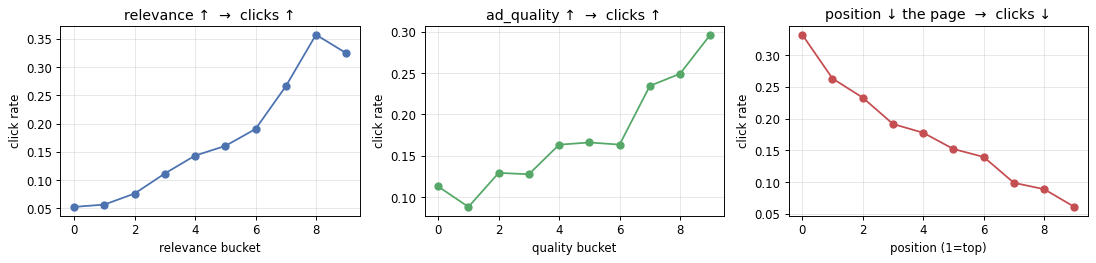

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
data["rel_b"] = pd.cut(data.relevance, 10, labels=False)
ax[0].plot(data.groupby("rel_b").clicked.mean().values, "o-", color=BLUE)
ax[0].set_title("relevance ↑  →  clicks ↑"); ax[0].set_xlabel("relevance bucket")
data["q_b"] = pd.cut(data.ad_quality, 10, labels=False)
ax[1].plot(data.groupby("q_b").clicked.mean().values, "o-", color=GREEN)
ax[1].set_title("ad_quality ↑  →  clicks ↑"); ax[1].set_xlabel("quality bucket")
ax[2].plot(data.groupby("position").clicked.mean().values, "o-", color=RED)
ax[2].set_title("position ↓ the page  →  clicks ↓"); ax[2].set_xlabel("position (1=top)")
for a in ax: a.set_ylabel("click rate")
plt.show()

## Step 3 · Split into training and test sets

Never grade a model on the examples it studied — that's like giving a student the exam
answers. We keep **75%** to learn from (*train*) and hide **25%** to grade on (*test*).
We also separate the **features** `X` from the **label** `y`. `true_pctr` is NOT a feature
(in real life you never know it) — we only carry it along to grade ourselves at the end.

In [5]:
from sklearn.model_selection import train_test_split

features = ["relevance", "position", "ad_quality", "is_mobile"]
X = data[features].to_numpy(dtype=float)
y = data["clicked"].to_numpy()

X_train, X_test, y_train, y_test, pctr_train, pctr_test = train_test_split(
    X, y, data.true_pctr.to_numpy(), test_size=0.25, random_state=42, stratify=y)
print("train impressions:", len(X_train), "| test impressions:", len(X_test))
print("click rate  train:", round(y_train.mean(),3), "| test:", round(y_test.mean(),3),
      " (stratify kept them equal)")

train impressions: 4500 | test impressions: 1500
click rate  train: 0.174 | test: 0.174  (stratify kept them equal)


## Step 4 · Standardize the features (put them on the same scale)

Our features live on different scales: `position` goes up to 10, the others up to 1. If we
train directly, `position` would shout over the others and learning would crawl. So we
**standardize**: subtract the mean and divide by the standard deviation, so every feature
becomes "how many standard deviations from average" (mean 0, spread 1).

We learn the mean/std on **train only** (Step 3's rule — never peek at the test set), then
apply the same transform to the test set.

In [6]:
mu = X_train.mean(axis=0)          # learned on TRAIN only
sd = X_train.std(axis=0)
Xtr = (X_train - mu) / sd          # standardized train
Xte = (X_test  - mu) / sd          # same transform applied to test

for f, m, s in zip(features, mu, sd):
    print(f"{f:<11} mean {m:6.2f}  std {s:5.2f}   (after: mean 0, std 1)")

relevance   mean   0.50  std  0.29   (after: mean 0, std 1)
position    mean   5.50  std  2.88   (after: mean 0, std 1)
ad_quality  mean   0.51  std  0.29   (after: mean 0, std 1)
is_mobile   mean   0.50  std  0.50   (after: mean 0, std 1)


## Step 5 · The three pieces of math (in plain words)

A pCTR model has just three parts. We'll write each as a tiny function.

1. **Sigmoid** — turns any score into a probability between 0 and 1. Big positive score →
   near 1; big negative → near 0; score of 0 → 0.5.
   $$\sigma(z)=\frac{1}{1+e^{-z}}$$
2. **Log loss** — how *wrong* a predicted probability is. It punishes being confident **and**
   wrong very hard (predicting 0.99 when there was no click hurts a lot).
   $$\ell=-\big[y\log p+(1-y)\log(1-p)\big]$$
3. **Gradient** — which direction to nudge each weight to make the loss smaller. For this
   model it's beautifully simple: **(prediction − actual) × feature**.

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, p):
    p = np.clip(p, 1e-9, 1 - 1e-9)               # avoid log(0)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

# quick sanity check so we trust these functions
print("sigmoid(0)   =", sigmoid(0.0), "  (a score of 0 means 50/50)")
print("sigmoid(+4)  =", round(sigmoid(4.0), 3), " (high score -> near 1)")
print("sigmoid(-4)  =", round(sigmoid(-4.0), 3), " (low score  -> near 0)")
print("log_loss when we predict 0.99 but there was NO click:", round(log_loss(np.array([0]), np.array([0.99])), 2), "(ouch)")

sigmoid(0)   = 0.5   (a score of 0 means 50/50)
sigmoid(+4)  = 0.982  (high score -> near 1)
sigmoid(-4)  = 0.018  (low score  -> near 0)
log_loss when we predict 0.99 but there was NO click: 4.61 (ouch)


## Step 6 · Train the model — and watch it learn (logging!)

This is the heart of the notebook. "Training" = start with all weights at 0, and repeat:
1. **predict** every impression's click probability with the current weights,
2. measure how wrong we are (**log loss**),
3. compute the **gradient** and take a small step to reduce the loss,
4. repeat for many rounds (*epochs*).

We **print the loss every 300 epochs** so you can literally see it going down — that's the
model learning. The step size (`lr`) controls how big each nudge is.

In [8]:
n_features = Xtr.shape[1]
w = np.zeros(n_features)      # one weight per feature, all start at 0
b = 0.0                       # the bias / intercept
lr = 0.3                      # learning rate = step size
epochs = 3000

loss_history = []
print("epoch |  loss   | weights (relevance, position, ad_quality, is_mobile)")
for epoch in range(epochs):
    p = sigmoid(Xtr @ w + b)          # 1) predict
    loss = log_loss(y_train, p)       # 2) how wrong?
    loss_history.append(loss)

    error = p - y_train               # 3) gradient = (prediction - actual) * feature
    grad_w = Xtr.T @ error / len(y_train)
    grad_b = error.mean()
    w -= lr * grad_w                  # 4) step downhill
    b -= lr * grad_b

    if epoch % 300 == 0:
        print(f"{epoch:5d} | {loss:.4f} | {np.round(w, 2)}")
print(f"{epochs:5d} | {loss_history[-1]:.4f} | {np.round(w, 2)}   <- final")

epoch |  loss   | weights (relevance, position, ad_quality, is_mobile)
    0 | 0.6931 | [ 0.03 -0.02  0.02  0.  ]
  300 | 0.3837 | [ 0.87 -0.66  0.53  0.17]
  600 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
  900 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 1200 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 1500 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 1800 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 2100 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 2400 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 2700 | 0.3837 | [ 0.87 -0.66  0.53  0.18]
 3000 | 0.3837 | [ 0.87 -0.66  0.53  0.18]   <- final


## Step 7 · The learning curve

The numbers above, as a picture. A healthy training run shows the loss dropping fast at
first, then flattening as the model runs out of things to learn. A flat line at the end
means "done."

loss went from 0.693 to 0.384


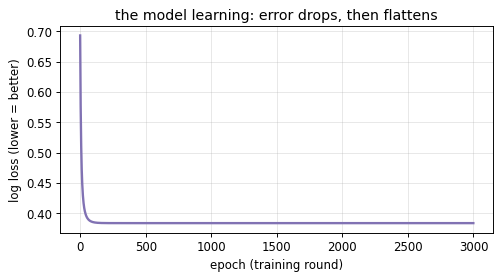

In [9]:
plt.figure(figsize=(6, 3.4))
plt.plot(loss_history, color=PURPLE, lw=2)
plt.xlabel("epoch (training round)"); plt.ylabel("log loss (lower = better)")
plt.title("the model learning: error drops, then flattens"); plt.show()
print("loss went from", round(loss_history[0], 3), "to", round(loss_history[-1], 3))

## Step 8 · Did it recover the TRUE rule?

We trained on **standardized** features, so the weights are in that scaled space. To
compare with the true rule from Step 1b, we convert them back to the original scale
(`weight / std`). If our model worked, these should land close to the true weights we
secretly used. This is a direct proof the model learned the real pattern from examples
alone.

feature       learned    true
relevance        3.02    3.00
position        -0.23   -0.25
ad_quality       1.85    1.50
is_mobile        0.35    0.40
intercept       -3.33   -3.00


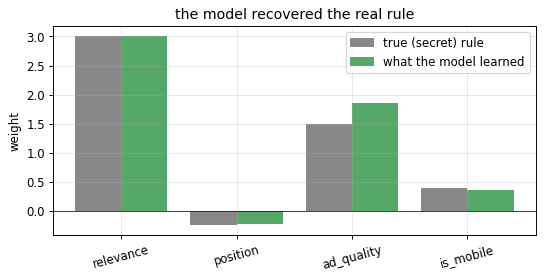

In [10]:
w_raw = w / sd                            # convert standardized weights back to original scale
b_raw = b - (w * mu / sd).sum()

print(f"{'feature':<11} {'learned':>9} {'true':>7}")
for f, wl in zip(features, w_raw):
    print(f"{f:<11} {wl:>9.2f} {TRUE_WEIGHTS[f]:>7.2f}")
print(f"{'intercept':<11} {b_raw:>9.2f} {TRUE_BIAS:>7.2f}")

x = np.arange(len(features))
plt.figure(figsize=(6.5, 3.4))
plt.bar(x - 0.2, [TRUE_WEIGHTS[f] for f in features], 0.4, color=GRAY, label="true (secret) rule")
plt.bar(x + 0.2, w_raw, 0.4, color=GREEN, label="what the model learned")
plt.axhline(0, color="k", lw=.6); plt.xticks(x, features, rotation=15)
plt.ylabel("weight"); plt.legend(); plt.title("the model recovered the real rule"); plt.show()

## Step 9 · Make predictions on unseen impressions

Now use the trained weights to predict click probabilities for the **test** set — data the
model never saw. `sigmoid(features · weights + bias)` gives a probability per impression.

In [11]:
pred_pctr = sigmoid(Xte @ w + b)          # predicted click probability, 0..1
show = pd.DataFrame(X_test, columns=features)
show["predicted_pctr"] = pred_pctr.round(3)
show["actually_clicked"] = y_test
print("a few predictions on impressions the model never saw:")
print(show.head(6).to_string(index=False))

a few predictions on impressions the model never saw:
 relevance  position  ad_quality  is_mobile  predicted_pctr  actually_clicked
  0.968401       1.0    0.888908        1.0           0.795                 1
  0.526212       7.0    0.704388        1.0           0.155                 1
  0.454595       2.0    0.383822        1.0           0.204                 0
  0.549080       5.0    0.693547        0.0           0.177                 0
  0.522677       8.0    0.480183        1.0           0.087                 0
  0.130573       2.0    0.374903        0.0           0.063                 0


## Step 10 · Does it *rank* well? (ROC and AUC)

A ranking model's first job is **ordering**: clicked ads should score higher than
non-clicked ones. **AUC** measures exactly that:

> pick one clicked and one non-clicked impression at random — AUC is the chance the model
> scored the clicked one higher.

0.5 = coin flip, 1.0 = perfect. Real ad models sit around 0.7–0.8.

AUC on unseen test data: 0.779


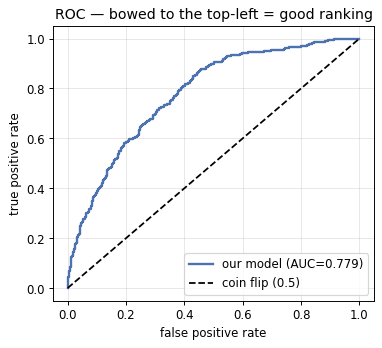

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test, pred_pctr)
fpr, tpr, _ = roc_curve(y_test, pred_pctr)
print("AUC on unseen test data:", round(auc, 3))

plt.figure(figsize=(4.6, 4.2))
plt.plot(fpr, tpr, color=BLUE, lw=2, label=f"our model (AUC={auc:.3f})")
plt.plot([0,1],[0,1], "k--", label="coin flip (0.5)")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC — bowed to the top-left = good ranking"); plt.legend(); plt.show()

## Step 11 · Are the probabilities *honest*? (calibration)

Ranking isn't enough: ad systems multiply pCTR by the bid, so the number itself must be
truthful. **Calibration** checks that among impressions scored ~0.20, about 20% really get
clicked. We bucket by predicted probability and plot predicted (x) vs actual click rate
(y). On the diagonal = honest.

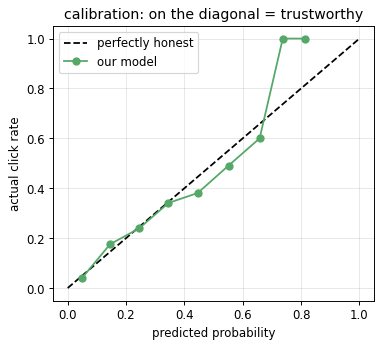

In [13]:
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_test, pred_pctr, n_bins=10)
plt.figure(figsize=(4.6, 4.2))
plt.plot([0,1],[0,1], "k--", label="perfectly honest")
plt.plot(mean_pred, frac_pos, "o-", color=GREEN, label="our model")
plt.xlabel("predicted probability"); plt.ylabel("actual click rate")
plt.title("calibration: on the diagonal = trustworthy"); plt.legend(); plt.show()

## Step 12 · Rank the ads — do clicked ones rise to the top?

The product output. Sort all impressions by predicted pCTR (highest first). A good model
puts the actually-clicked ones near the top. We log their **average rank** and show the
score histograms for clicked vs non-clicked — clicked (green) should sit to the right.

clicked impressions land at average rank 405 out of 1500  (top 27%)


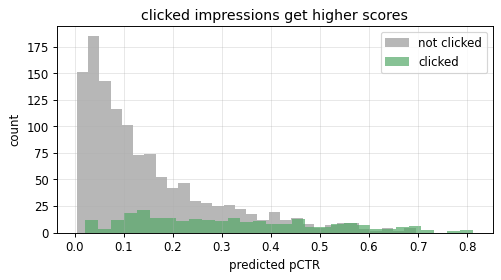

In [14]:
order = np.argsort(-pred_pctr)
ranks = np.empty_like(order); ranks[order] = np.arange(1, len(order)+1)
clicked_ranks = ranks[y_test == 1]
print(f"clicked impressions land at average rank {clicked_ranks.mean():.0f} "
      f"out of {len(ranks)}  (top {100*clicked_ranks.mean()/len(ranks):.0f}%)")

plt.figure(figsize=(6, 3.4))
plt.hist(pred_pctr[y_test == 0], bins=30, alpha=.6, color=GRAY, label="not clicked")
plt.hist(pred_pctr[y_test == 1], bins=30, alpha=.7, color=GREEN, label="clicked")
plt.xlabel("predicted pCTR"); plt.ylabel("count")
plt.title("clicked impressions get higher scores"); plt.legend(); plt.show()

## Step 13 · pCTR × bid — ranking by *value*, not just clicks

An ad system wants **value**, not only clicks. Compare advertisers by
**expected value = pCTR × bid** (expected money per impression). A slightly less likely
click on a big bid can beat a likely click on a tiny bid. This is why **calibration
mattered** — a wrong probability makes this arithmetic wrong.

ad  bid  pctr  expected_value
 A  8.0  0.01            0.08
 B  3.0  0.04            0.12
 C  5.0  0.02            0.10

Winner: Ad B (value 0.120) — not the biggest bid, not blindly the biggest pCTR.


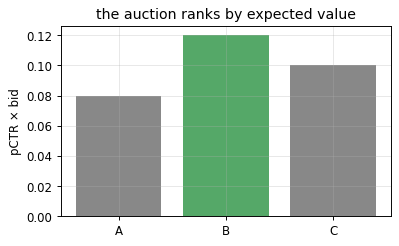

In [15]:
cand = pd.DataFrame({"ad": ["A","B","C"], "bid": [8.0, 3.0, 5.0], "pctr": [0.010, 0.040, 0.020]})
cand["expected_value"] = cand.pctr * cand.bid
print(cand.to_string(index=False))
win = cand.sort_values("expected_value", ascending=False).iloc[0]
print(f"\nWinner: Ad {win.ad} (value {win.expected_value:.3f}) — not the biggest bid, not blindly the biggest pCTR.")
plt.figure(figsize=(4.8, 3))
plt.bar(cand.ad, cand.expected_value, color=[GRAY, GREEN, GRAY])
plt.ylabel("pCTR × bid"); plt.title("the auction ranks by expected value"); plt.show()

## Step 14 · The proof — four graphs it's working

Because we invented the true click probability, we can compare predictions to reality:
1. **Predicted vs TRUE pCTR** — dots on the diagonal = recovered the real probability.
2. **Calibration** — predicted vs observed click rate on the diagonal = honest.
3. **Score distributions** — clicked (green) clearly right of not-clicked (grey).
4. **Predicted vs actual by group** — 10 groups low→high; bars (predicted) and dots
   (actual) match.

AUC=0.779 | predicted-vs-true correlation=0.995 — the pipeline works.


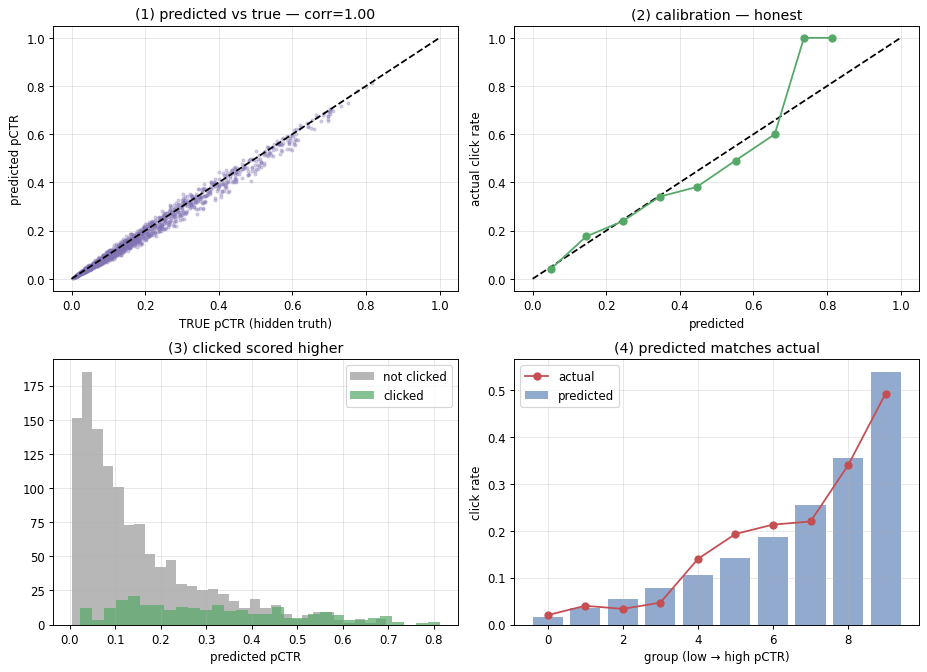

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
corr = np.corrcoef(pctr_test, pred_pctr)[0, 1]
ax[0,0].scatter(pctr_test, pred_pctr, s=6, alpha=.3, color=PURPLE); ax[0,0].plot([0,1],[0,1],"k--")
ax[0,0].set_xlabel("TRUE pCTR (hidden truth)"); ax[0,0].set_ylabel("predicted pCTR")
ax[0,0].set_title(f"(1) predicted vs true — corr={corr:.2f}")

frac_pos, mean_pred = calibration_curve(y_test, pred_pctr, n_bins=10)
ax[0,1].plot([0,1],[0,1],"k--"); ax[0,1].plot(mean_pred, frac_pos, "o-", color=GREEN)
ax[0,1].set_xlabel("predicted"); ax[0,1].set_ylabel("actual click rate"); ax[0,1].set_title("(2) calibration — honest")

ax[1,0].hist(pred_pctr[y_test==0], bins=30, alpha=.6, color=GRAY, label="not clicked")
ax[1,0].hist(pred_pctr[y_test==1], bins=30, alpha=.7, color=GREEN, label="clicked")
ax[1,0].legend(); ax[1,0].set_title("(3) clicked scored higher"); ax[1,0].set_xlabel("predicted pCTR")

dec = pd.qcut(pred_pctr, 10, labels=False, duplicates="drop")
gdf = pd.DataFrame({"d": dec, "pred": pred_pctr, "act": y_test}).groupby("d").mean()
ax[1,1].bar(gdf.index, gdf.pred, color=BLUE, alpha=.6, label="predicted")
ax[1,1].plot(gdf.index, gdf.act, "o-", color=RED, label="actual")
ax[1,1].set_xlabel("group (low → high pCTR)"); ax[1,1].set_ylabel("click rate")
ax[1,1].legend(); ax[1,1].set_title("(4) predicted matches actual")
plt.tight_layout(); plt.show()
print(f"AUC={auc:.3f} | predicted-vs-true correlation={corr:.3f} — the pipeline works.")

---
## What you just did

You built a **pCTR model from scratch** and watched every step:
1. Made data with features + a click label.
2. Explored it; split train/test; **standardized** features.
3. Wrote the **sigmoid, log loss, and gradient** yourself.
4. **Trained** with a loop, logging the loss as it fell (Steps 6–7).
5. Proved it **recovered the true rule** (Step 8).
6. Predicted, then measured **ranking (AUC)** and **honesty (calibration)**.
7. Ranked ads and combined **pCTR × bid** for the auction.
8. Confirmed correctness with **four proof graphs**.

**Where this sits in M7:** this was a single **pointwise pCTR** head (M7.1). M7.2 adds
pairwise/listwise ranking; M7.3 adds multi-objective heads (click + dwell + value) and CTR
architectures. The calibration you saw is what module **M8** teaches you to measure and
repair. **Next:** the companion *full pipeline* notebook trains **CTR + VTR + LTR together
with user history** — the shape of a real production ranker.